# Problem 1: Custom Maze Environment Setup

In this section, we define the custom gridworld maze environment (`SimpleEnv`) and render it to verify its structure.


In [1]:
import os
import random
import math
import datetime
import io
import imageio
from base64 import b64encode
from IPython.display import HTML, display
from collections import deque
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.tensorboard import SummaryWriter
from minigrid.wrappers import RGBImgObsWrapper
from minigrid.minigrid_env import MiniGridEnv, MissionSpace
from minigrid.core.grid import Grid
from minigrid.core.world_object import Goal, Wall

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


class SimpleEnv(MiniGridEnv):
    # Set size to 8 to secure internal 6x6 space
    def __init__(self, size=8, agent_start_pos=(1,1), agent_start_dir=0, max_steps: int | None = None, agent_view_size=3, **kwargs):
        self.agent_start_pos = agent_start_pos
        self.agent_start_dir = agent_start_dir
        mission_space = MissionSpace(mission_func=self._gen_mission)
        super().__init__(mission_space=mission_space, grid_size=size, max_steps=100, agent_view_size=agent_view_size, **kwargs)

    @staticmethod
    def _gen_mission():
        return "grand mission"

    def _gen_grid(self, width, height):
        self.grid = Grid(width, height)
        self.grid.wall_rect(0, 0, width, height)

        # [Custom Complex Maze] Create crossroads and dead ends

        # 1. Top part: Lead agent to a dead end to deceive it
        self.grid.set(2, 2, Wall())
        self.grid.set(3, 2, Wall())
        self.grid.set(4, 1, Wall())
        self.grid.set(4, 2, Wall())
        self.grid.set(6, 2, Wall())

        # 2. Middle part: Create walls and bifurcated paths
        self.grid.set(1, 4, Wall())
        # self.grid.set(2, 4, Wall())
        self.grid.set(3, 4, Wall())
        self.grid.set(4, 4, Wall())
        # self.grid.set(5, 4, Wall())
        self.grid.set(6, 3, Wall())

        # 3. Bottom part: Obstacle in front of final destination
        # self.grid.set(4, 5, Wall())
        # self.grid.set(2, 6, Wall())
        self.grid.set(3, 5, Wall())
        self.grid.set(5, 6, Wall())

        # Set Goal position at (6, 6)
        self.grid.set(width - 2, height - 2, Goal())

        # Set agent start position and direction
        if self.agent_start_pos is not None:
            self.agent_pos = self.agent_start_pos
            self.agent_dir = self.agent_start_dir
        else:
            self.place_agent()

        self.mission = "grand mission"


Using device: cuda


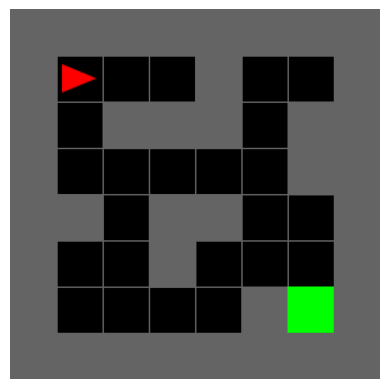

In [2]:
import matplotlib.pyplot as plt

env = SimpleEnv(render_mode="rgb_array")
env.reset()
env.unwrapped.highlight = False

image_data = env.render()
plt.imshow(image_data)
plt.axis("off")
plt.show()

# Problem 2: Tabular Reinforcement Learning (Q-Learning & SARSA)


In [3]:
# 1. Epsilon-Greedy Policy Function
def eps_greedy(Q_values, state, epsilon=1.0):
    x, y, d = state[0], state[1], state[2]

    if np.random.rand() < epsilon:
        # Exploration: Select randomly from 0 (Left), 1 (Right), 2 (Forward)
        action = np.random.randint(0, 3)
    else:
        # Exploitation: Select the action with the highest Q-value in the current state
        action = np.argmax(Q_values[x, y, d])
    return action

# 2. Reward Plotting Function
def reward_plot(total_reward):
    plt.plot(total_reward, label="Total Reward per Episode")
    plt.xlabel("Episodes")
    plt.ylabel("Total Reward")
    plt.legend()
    plt.show()

# 3. Q-Learning Main Loop
def run_q_learning(env, Q_values, n_episodes, epsilon, epsilon_decay, gamma, lr):
    total_reward = []

    for i in tqdm(range(n_episodes), desc="Simulating environment", unit="step"):
        obs, info = env.reset(seed=42)

        # Convert state to array indices (subtract 1 to start from 0)
        state = np.array([env.agent_pos[0]-1, env.agent_pos[1]-1, obs["direction"]])
        done = False
        reward_sum = 0

        while not done:
            action = eps_greedy(Q_values, state, epsilon)

            # Take action in the environment
            next_obs, reward, terminated, truncated, info = env.step(action)

            # Define next state
            next_state = np.array([env.agent_pos[0]-1, env.agent_pos[1]-1, next_obs["direction"]])

            # Extract coordinate variables
            x, y, d = state[0], state[1], state[2]
            nx, ny, nd = next_state[0], next_state[1], next_state[2]

            # Q-value update logic (Calculate TD Error)
            best_next_action = np.argmax(Q_values[nx, ny, nd])
            td_target = reward + gamma * Q_values[nx, ny, nd, best_next_action]
            td_error = td_target - Q_values[x, y, d, action]

            Q_values[x, y, d, action] += lr * td_error

            # Update state and reward
            state = next_state
            reward_sum += reward
            done = terminated or truncated

        total_reward.append(reward_sum)

        # 💡 Epsilon decay at the end of the episode (limit to min 0.01)
        epsilon = max(epsilon * epsilon_decay, 0.01)

    return Q_values, total_reward

Starting Q-Learning training... (This may take a while)


Simulating environment: 100%|██████████| 50000/50000 [01:00<00:00, 826.26step/s] 


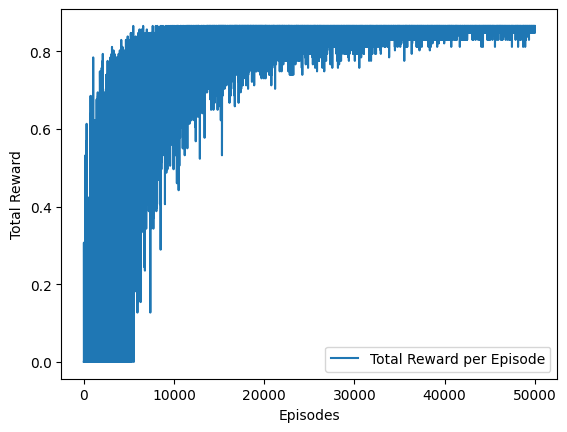

Training complete!


In [4]:
from tqdm import tqdm
import numpy as np
def main():
    env = SimpleEnv(render_mode="rgb_array")

    # Initialize Q-Table: Array of dimensions (width 6, height 6, directions 4, actions 3)
    Q_values_init = np.zeros((env.width-2, env.height-2, 4, 3))

    # 💡 Key Modification: Increase episodes to 50,000 and slow down epsilon decay
    epsilon = 1.0
    epsilon_decay = 0.9999
    gamma = 0.99
    lr = 0.005
    n_episodes = 50000

    print("Starting Q-Learning training... (This may take a while)")
    Q_values, total_reward = run_q_learning(
        env, Q_values_init, n_episodes, epsilon, epsilon_decay, gamma, lr
    )

    # Plot training results
    reward_plot(total_reward)
    print("Training complete!")

    return Q_values, total_reward

# Execute
learned_Q, q_learning_rewards = main()


In [5]:
import io
import imageio
from base64 import b64encode
from IPython.display import HTML, display
import numpy as np # Import numpy in case of error

# 1. Video generation function (Page 37 of textbook)
def display_video(frames, fps=10, filename=None):
    if isinstance(fps, str):
        filename = fps
        fps = 10
    os.makedirs("video_obs3", exist_ok=True)
    if filename:
        save_path = os.path.join("video_obs3", filename)
        imageio.mimsave(save_path, frames, format="mp4", fps=fps)
        print(f"Video saved to {save_path}")
    video_buffer = io.BytesIO()
    imageio.mimsave(video_buffer, frames, format="mp4", fps=fps)
    video_buffer.seek(0)
    video_base64 = b64encode(video_buffer.read()).decode()

    video_html = f"""
    <video width="640" height="480" controls autoplay>
    <source src="data:video/mp4;base64,{video_base64}" type="video/mp4">
    </video>
    """
    display(HTML(video_html))

# 2. Test trained Q-values and capture frames (Page 38 of textbook)
def test_and_display(Q_values):
    env = SimpleEnv(render_mode="rgb_array")
    obs, info = env.reset(seed=42)

    # Initialize state list
    state = np.array([env.agent_pos[0]-1, env.agent_pos[1]-1, obs["direction"]])
    done = False
    frames = []
    frames.append(env.render())

    i = 0
    while not done:
        # During testing, set epsilon to 0 to only exploit the learned policy
        x, y, d = state[0], state[1], state[2]
        action = np.argmax(Q_values[x, y, d])

        # Take action in the environment
        next_obs, reward, terminated, truncated, info = env.step(action)
        state = np.array([env.agent_pos[0]-1, env.agent_pos[1]-1, next_obs["direction"]])
        done = terminated or truncated

        frames.append(env.render())
        i += 1

        # Prevent the agent from falling into an infinite loop if it fails to find the path
        if i > 100:
            print("Shortest path search failed (Prevented infinite loop)")
            break

    env.close()
    print(f"Finished at the {i}-th iteration")

    # 3. Display video
    display_video(frames)

# Execute: Pass the learned_Q variable trained in the previous block.
test_and_display(learned_Q)


Finished at the 15-th iteration


## SARSA Implementation
In this section, we implement the SARSA algorithm (On-policy TD Control) and compare it with Q-learning.


Starting SARSA training... (This may take a while)


Simulating SARSA: 100%|██████████| 50000/50000 [01:01<00:00, 819.08step/s] 


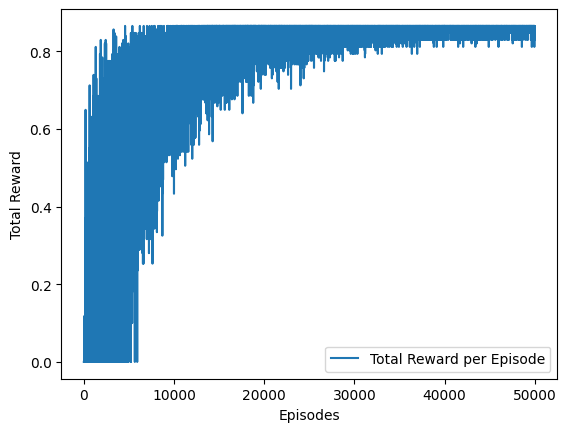

SARSA training complete!


In [6]:
# 4. SARSA Main Loop
def run_sarsa(env, Q_values, n_episodes, epsilon, epsilon_decay, gamma, lr):
    total_reward = []

    for i in tqdm(range(n_episodes), desc="Simulating SARSA", unit="step"):
        obs, info = env.reset(seed=42)

        # Convert state to array indices
        state = np.array([env.agent_pos[0]-1, env.agent_pos[1]-1, obs["direction"]])
        done = False
        reward_sum = 0

        # On-policy: Select action A in the current state
        action = eps_greedy(Q_values, state, epsilon)

        while not done:
            # Take action A -> Next state S' and reward R
            next_obs, reward, terminated, truncated, info = env.step(action)
            next_state = np.array([env.agent_pos[0]-1, env.agent_pos[1]-1, next_obs["direction"]])

            # On-policy: Select next action A' in the next state S' according to policy
            next_action = eps_greedy(Q_values, next_state, epsilon)

            # Extract coordinate variables
            x, y, d = state[0], state[1], state[2]
            nx, ny, nd = next_state[0], next_state[1], next_state[2]

            # Q-value update logic (SARSA Update Formula)
            td_target = reward + gamma * Q_values[nx, ny, nd, next_action]
            td_error = td_target - Q_values[x, y, d, action]
            Q_values[x, y, d, action] += lr * td_error

            # Update state and action
            state = next_state
            action = next_action
            reward_sum += reward
            done = terminated or truncated

        total_reward.append(reward_sum)

        # Epsilon decay at the end of the episode
        epsilon = max(epsilon * epsilon_decay, 0.01)

    return Q_values, total_reward

def main_sarsa():
    env = SimpleEnv(render_mode="rgb_array")
    Q_values_init = np.zeros((env.width-2, env.height-2, 4, 3))

    epsilon = 1.0
    epsilon_decay = 0.9999
    gamma = 0.99
    lr = 0.005
    n_episodes = 50000

    print("Starting SARSA training... (This may take a while)")
    Q_values, total_reward = run_sarsa(
        env, Q_values_init, n_episodes, epsilon, epsilon_decay, gamma, lr
    )

    # Plot training results
    reward_plot(total_reward)
    print("SARSA training complete!")
    return Q_values, total_reward

learned_Q_sarsa, sarsa_rewards = main_sarsa()

In [7]:
# Test SARSA results and capture frames
print("--- Testing SARSA Results ---")
test_and_display(learned_Q_sarsa)

--- Testing SARSA Results ---
Finished at the 15-th iteration


## Q-Learning vs SARSA Comparison
Here, we compare the training curves of Q-Learning (Off-policy) and SARSA (On-policy) to understand their convergence behaviors in this maze environment.


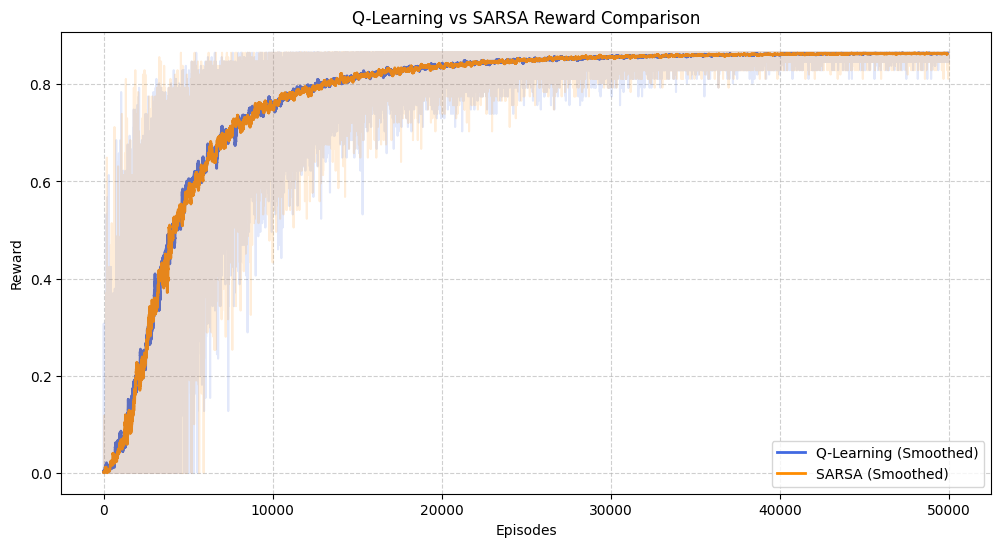

In [8]:
# Visualize training curves comparison: Q-Learning vs SARSA
def compare_plots(q_rewards, sarsa_rewards, window_size=100):
    def moving_average(data, window=window_size):
        return np.convolve(data, np.ones(window)/window, mode='valid')

    plt.figure(figsize=(12, 6))
    
    # Smoothed curves
    plt.plot(moving_average(q_rewards), label="Q-Learning (Smoothed)", color="royalblue", linewidth=2)
    plt.plot(moving_average(sarsa_rewards), label="SARSA (Smoothed)", color="darkorange", linewidth=2)
    
    # Raw rewards (transparent)
    plt.plot(q_rewards, color="royalblue", alpha=0.15)
    plt.plot(sarsa_rewards, color="darkorange", alpha=0.15)
    
    plt.xlabel("Episodes")
    plt.ylabel("Reward")
    plt.title("Q-Learning vs SARSA Reward Comparison")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

compare_plots(q_learning_rewards, sarsa_rewards)

# Problem 3: Deep Reinforcement Learning (DQN)
In this section, we implement a Deep Q-Network (DQN) to solve the same maze environment.
We will compare two different preprocessing approaches:
1. **Grayscale input** (1 channel)
2. **RGB input** (3 channels)


In [9]:
import os
import random
import math
import datetime
import io
import imageio
from base64 import b64encode
from IPython.display import HTML, display
from collections import deque
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.tensorboard import SummaryWriter
from minigrid.wrappers import RGBImgObsWrapper
from minigrid.minigrid_env import MiniGridEnv, MissionSpace
from minigrid.core.grid import Grid
from minigrid.core.world_object import Goal, Wall

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

os.makedirs("policy_obs3", exist_ok=True)
os.makedirs("video_obs3", exist_ok=True)

def get_model_save_path(run_name):
    os.makedirs("policy_obs3", exist_ok=True)
    return os.path.join("policy_obs3", f"{run_name}_save.pth")

def load_model(model, run_name, filename=None):
    if filename is None:
        filename = f"{run_name}_save.pth"
    if not filename.startswith("policy_obs3/") and not filename.startswith("policy_obs3\\"):
        path = os.path.join("policy_obs3", filename)
    else:
        path = filename
    model.load_state_dict(torch.load(path, map_location=device))
    print(f"Model loaded from {path}")
    return model

def display_video(frames, fps=10, filename=None):
    if isinstance(fps, str):
        filename = fps
        fps = 10
    os.makedirs("video_obs3", exist_ok=True)
    if filename:
        save_path = os.path.join("video_obs3", filename)
        imageio.mimsave(save_path, frames, format="mp4", fps=fps)
        print(f"Video saved to {save_path}")
    video_buffer = io.BytesIO()
    imageio.mimsave(video_buffer, frames, format="mp4", fps=fps)
    video_buffer.seek(0)
    video_base64 = b64encode(video_buffer.read()).decode()
    video_html = f'<video width="640" height="480" controls autoplay><source src="data:video/mp4;base64,{video_base64}" type="video/mp4"></video>'
    display(HTML(video_html))


Using device: cuda


In [10]:
def pre_state(obs, use_grayscale=True):
    # Extract and normalize image to [0, 1]
    state = obs['image'] / 255.0
    # Convert to PyTorch tensor and permute to (C, H, W)
    state = torch.tensor(state, dtype=torch.float32).permute(2, 0, 1)
    if use_grayscale:
        # Convert 3-channel RGB to 1-channel Grayscale
        to_grayscale = transforms.Grayscale(num_output_channels=1)
        state = to_grayscale(state)
    return state

In [11]:
class ReplayBuffer(object):
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
        
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
        
    def sample(self, batch_size):
        state, action, reward, next_state, done = zip(*random.sample(self.buffer, batch_size))
        return torch.stack(state), action, reward, torch.stack(next_state), done
        
    def __len__(self):
        return len(self.buffer)

In [12]:
class Model(nn.Module):
    def __init__(self, input_shape, num_actions):
        super(Model, self).__init__()
        in_channels = input_shape[0] # 1 for grayscale, 3 for RGB
        
        self.conv1 = nn.Conv2d(in_channels, 16, kernel_size=5, stride=2, padding=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(32, 32, kernel_size=3, stride=2, padding=1)
        
        # input 64x64 -> conv1 output is 32x32 -> conv2 output is 16x16 -> conv3 output is 8x8
        # flattened size: 32 * 8 * 8 = 2048
        self.fc1 = nn.Linear(32 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, num_actions)
        
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.reshape(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [13]:
def eps_greedy(model, state, epsilon):
    if random.random() < epsilon:
        action = random.randint(0, 2) # Left, Right, Forward
    else:
        state_tensor = state.unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = model(state_tensor)
            action = q_values.argmax(dim=1).item()
    return action

def update_target(current_model, target_model):
    target_model.load_state_dict(current_model.state_dict())

def compute_td_error(batch_size, replay_buffer, model, target_model, gamma, optimizer):
    if batch_size > len(replay_buffer):
        return None
        
    state, action, reward, next_state, done = replay_buffer.sample(batch_size)
    
    state = state.to(device)
    next_state = next_state.to(device)
    
    action = torch.tensor(action, dtype=torch.long).unsqueeze(1).to(device)
    reward = torch.tensor(reward, dtype=torch.float32).unsqueeze(1).to(device)
    mask = torch.tensor(1 - np.float32(done), dtype=torch.float32).unsqueeze(1).to(device)
    
    q_values = model(state)
    q_value = q_values.gather(1, action)
    
    with torch.no_grad():
        next_q_values = target_model(next_state)
        next_q_value = next_q_values.max(dim=1, keepdim=True)[0]
        td_target = reward + gamma * next_q_value * mask
        
    loss = F.mse_loss(q_value, td_target)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    return loss.item()

In [14]:
def run_dqn(use_grayscale=True, n_episodes=3000, lr=1e-4, batch_size=64, Target_Update=10, epsilon_decay=0.998, run_name="DQN"):
    env = SimpleEnv(render_mode="rgb_array")
    env = RGBImgObsWrapper(env)
    
    input_channels = 1 if use_grayscale else 3
    model = Model((input_channels, 64, 64), 3).to(device)
    target_model = Model((input_channels, 64, 64), 3).to(device)
    update_target(model, target_model)
    target_model.eval()
    
    optimizer = optim.RMSprop(model.parameters(), lr=lr)
    replay_buffer = ReplayBuffer(10000)
    
    writer = SummaryWriter(log_dir=f"runs_obs3/{run_name}")
    
    epsilon = 1.0
    epsilon_min = 0.01
    gamma = 0.99
    
    import copy
    total_rewards = []
    best_avg_reward = -float('inf')
    best_weights = copy.deepcopy(model.state_dict())
    goal = [env.width - 3, env.height - 3] # 0-indexed goal: [5, 5]
    
    progress_bar = tqdm(range(n_episodes), desc=f"Training {run_name}", unit="episode")
    for episode in progress_bar:
        obs, info = env.reset(seed=42)
        state = pre_state(obs, use_grayscale=use_grayscale)
        
        # Initial distance (0-indexed)
        distance = math.sqrt((goal[0] - (env.agent_pos[0]-1))**2 + (goal[1] - (env.agent_pos[1]-1))**2)
        done = False
        episode_reward = 0
        episode_shaped_reward = 0
        losses = []
        
        while not done:
            action = eps_greedy(model, state, epsilon)
            
            # Step in environment
            next_obs, reward, terminated, truncated, info = env.step(action)
            next_state = pre_state(next_obs, use_grayscale=use_grayscale)
            
            # 0-indexed next distance
            next_distance = math.sqrt((goal[0] - (env.agent_pos[0]-1))**2 + (goal[1] - (env.agent_pos[1]-1))**2)
            
            # Additional reward (reward shaping with penalty)
            shaped_reward = reward + (distance - next_distance) - 0.01
            
            # Store in replay buffer
            replay_buffer.push(state, action, shaped_reward, next_state, terminated)
            
            # Train
            loss = compute_td_error(batch_size, replay_buffer, model, target_model, gamma, optimizer)
            if loss is not None:
                losses.append(loss)
                
            state = next_state
            distance = next_distance
            episode_reward += reward
            episode_shaped_reward += shaped_reward
            done = terminated or truncated
            
        # Decay epsilon
        epsilon = max(epsilon * epsilon_decay, epsilon_min)
        
        # Update target network
        if episode % Target_Update == 0:
            update_target(model, target_model)
            
        # Logging
        mean_loss = np.mean(losses) if losses else 0
        total_rewards.append(episode_reward)
        
        # Track best weights
        recent_rewards_temp = total_rewards[-100:]
        avg_reward_temp = np.mean(recent_rewards_temp)
        if avg_reward_temp > best_avg_reward:
            best_avg_reward = avg_reward_temp
            best_weights = copy.deepcopy(model.state_dict())
        
        writer.add_scalar("Reward/True", episode_reward, episode)
        writer.add_scalar("Reward/Shaped", episode_shaped_reward, episode)
        writer.add_scalar("Loss", mean_loss, episode)
        writer.add_scalar("Epsilon", epsilon, episode)
        
        progress_bar.set_postfix({
            "True Reward": f"{episode_reward:.2f}",
            "Loss": f"{mean_loss:.4f}",
            "Epsilon": f"{epsilon:.3f}"
        })
        
    writer.close()
    
    # Save the trained model (best weights)
    save_path = get_model_save_path(run_name)
    torch.save(best_weights, save_path)
    print(f"Best model (avg reward: {best_avg_reward:.4f}) saved to {save_path}")
    model.load_state_dict(best_weights)
    return model, total_rewards


## 1. Train DQN with Grayscale Inputs

In [15]:
# Train grayscale model
model_grayscale, rewards_grayscale = run_dqn(
    use_grayscale=True,
    n_episodes=3000,
    lr=1e-4,
    batch_size=64,
    Target_Update=10,
    epsilon_decay=0.998,
    run_name="DQN_Grayscale"
)

/home/ash/projects/51_optimization_project3/.venv/lib/python3.10/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.width to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.width` for environment variables or `env.get_wrapper_attr('width')` that will search the reminding wrappers.
  logger.warn(
/home/ash/projects/51_optimization_project3/.venv/lib/python3.10/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.height to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.height` for environment variables or `env.get_wrapper_attr('height')` that will search the reminding wrappers.
  logger.warn(
Training DQN_Grayscale:   0%|          | 0/3000 [00:00<?, ?episode/s]/home/ash/projects/51_optimization_project3/.venv/lib/python3.10/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.agent_pos to get variables from other w

Best model (avg reward: 0.8648) saved to policy_obs3/DQN_Grayscale_save.pth


## 2. Train DQN with RGB (Color) Inputs

In [16]:
# Train RGB model
model_rgb, rewards_rgb = run_dqn(
    use_grayscale=False,
    n_episodes=3000,
    lr=1e-4,
    batch_size=64,
    Target_Update=10,
    epsilon_decay=0.998,
    run_name="DQN_RGB"
)

Training DQN_RGB: 100%|██████████| 3000/3000 [05:09<00:00,  9.69episode/s, True Reward=0.86, Loss=0.0011, Epsilon=0.010]

Best model (avg reward: 0.8636) saved to policy_obs3/DQN_RGB_save.pth


## 3. Compare and Test the Models

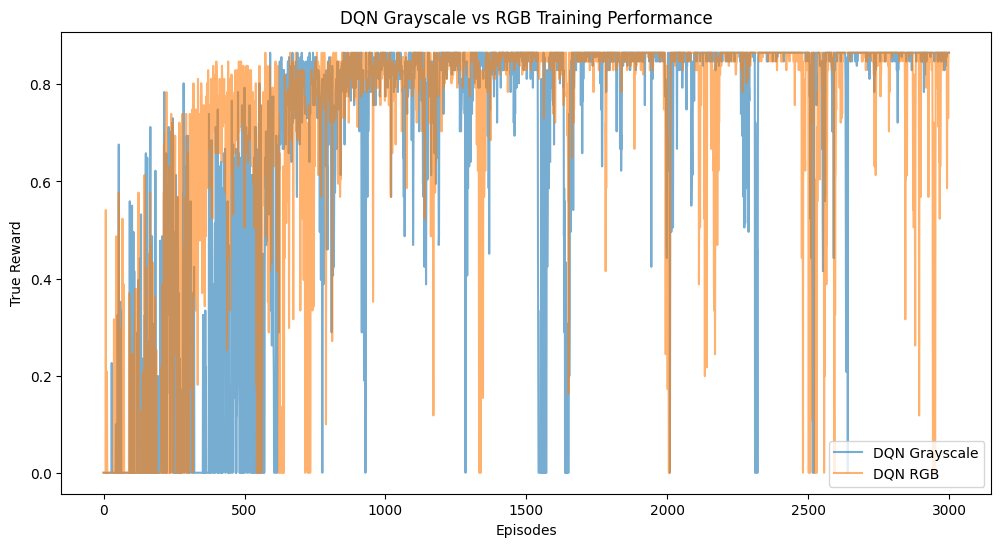

In [17]:
# Plot Comparison of True Rewards

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(rewards_grayscale, label="DQN Grayscale", alpha=0.6)
plt.plot(rewards_rgb, label="DQN RGB", alpha=0.6)
plt.xlabel("Episodes")
plt.ylabel("True Reward")
plt.title("DQN Grayscale vs RGB Training Performance")
plt.legend(loc='lower right')
plt.show()

In [18]:
# Test function for DQN models
def test_dqn(model, use_grayscale=True):
    env = SimpleEnv(render_mode="rgb_array")
    env = RGBImgObsWrapper(env)
    obs, info = env.reset(seed=42)
    state = pre_state(obs, use_grayscale=use_grayscale)
    done = False
    frames = [env.render()]
    
    steps = 0
    while not done and steps < 100:
        state_tensor = state.unsqueeze(0).to(device)
        with torch.no_grad():
            action = model(state_tensor).argmax(dim=1).item()
        next_obs, reward, terminated, truncated, info = env.step(action)
        state = pre_state(next_obs, use_grayscale=use_grayscale)
        done = terminated or truncated
        frames.append(env.render())
        steps += 1
        
    env.close()
    print(f"Finished in {steps} steps")
    return frames

print("Testing Grayscale Model...")
grayscale_frames = test_dqn(model_grayscale, use_grayscale=True)
display_video(grayscale_frames, filename="dqn_grayscale_play.mp4")

print("Testing RGB Model...")
rgb_frames = test_dqn(model_rgb, use_grayscale=False)
display_video(rgb_frames, filename="dqn_rgb_play.mp4")

Testing Grayscale Model...
Finished in 15 steps
Video saved to video_obs3/dqn_grayscale_play.mp4


Testing RGB Model...
Finished in 15 steps
Video saved to video_obs3/dqn_rgb_play.mp4


## DQN with Early Stopping

Introduce an early stopping condition that terminates training when the moving average of the last 100 episodes' True Reward reaches a threshold (0.84 or above) and Epsilon is 0.05 or lower. This reduces training time and prevents overfitting.


In [19]:
def run_dqn_early_stopping(use_grayscale=True, n_episodes=3000, lr=1e-4, batch_size=64, Target_Update=10, epsilon_decay=0.998, run_name="DQN_ES", target_avg_reward=0.84):
    env = SimpleEnv()
    env = RGBImgObsWrapper(env)
    
    input_channels = 1 if use_grayscale else 3
    model = Model((input_channels, 64, 64), 3).to(device)
    target_model = Model((input_channels, 64, 64), 3).to(device)
    update_target(model, target_model)
    target_model.eval()
    
    optimizer = optim.RMSprop(model.parameters(), lr=lr)
    replay_buffer = ReplayBuffer(10000)
    
    writer = SummaryWriter(log_dir=f"runs_obs3/{run_name}")
    
    epsilon = 1.0
    epsilon_min = 0.01
    gamma = 0.99
    
    import copy
    total_rewards = []
    best_avg_reward = -float('inf')
    best_weights = copy.deepcopy(model.state_dict())
    recent_rewards = deque(maxlen=100)
    goal = [env.width - 3, env.height - 3]
    
    progress_bar = tqdm(range(n_episodes), desc=f"Training {run_name}", unit="episode")
    for episode in progress_bar:
        obs, info = env.reset(seed=42)
        state = pre_state(obs, use_grayscale=use_grayscale)
        
        distance = math.sqrt((goal[0] - (env.agent_pos[0]-1))**2 + (goal[1] - (env.agent_pos[1]-1))**2)
        done = False
        episode_reward = 0
        episode_shaped_reward = 0
        losses = []
        
        while not done:
            action = eps_greedy(model, state, epsilon)
            next_obs, reward, terminated, truncated, info = env.step(action)
            next_state = pre_state(next_obs, use_grayscale=use_grayscale)
            
            next_distance = math.sqrt((goal[0] - (env.agent_pos[0]-1))**2 + (goal[1] - (env.agent_pos[1]-1))**2)
            
            # Additional reward
            shaped_reward = reward + (distance - next_distance) - 0.01
            
            replay_buffer.push(state, action, shaped_reward, next_state, terminated)
            
            loss = compute_td_error(batch_size, replay_buffer, model, target_model, gamma, optimizer)
            if loss is not None:
                losses.append(loss)
                
            state = next_state
            distance = next_distance
            episode_reward += reward
            episode_shaped_reward += shaped_reward
            done = terminated or truncated
            
        epsilon = max(epsilon * epsilon_decay, epsilon_min)
        
        if episode % Target_Update == 0:
            update_target(model, target_model)
            
        mean_loss = np.mean(losses) if losses else 0
        total_rewards.append(episode_reward)
        
        # Track best weights
        recent_rewards_temp = total_rewards[-100:]
        avg_reward_temp = np.mean(recent_rewards_temp)
        if avg_reward_temp > best_avg_reward:
            best_avg_reward = avg_reward_temp
            best_weights = copy.deepcopy(model.state_dict())
        recent_rewards.append(episode_reward)
        
        writer.add_scalar("Reward/True", episode_reward, episode)
        writer.add_scalar("Reward/Shaped", episode_shaped_reward, episode)
        writer.add_scalar("Loss", mean_loss, episode)
        writer.add_scalar("Epsilon", epsilon, episode)
        
        # Early Stopping Condition
        if len(recent_rewards) == 100:
            avg_reward = np.mean(recent_rewards)
            if avg_reward >= target_avg_reward and epsilon <= 0.05:
                print(f"\n[Early Stopping] Target average reward {target_avg_reward} achieved: {avg_reward:.4f} over last 100 episodes. Epsilon: {epsilon:.3f}. Stopping training at episode {episode+1}.")
                break
                
        if (episode + 1) % 100 == 0:
            print(f"[{run_name}] Episode {episode+1}/{n_episodes} - True Reward: {episode_reward:.2f}, Loss: {mean_loss:.4f}, Epsilon: {epsilon:.3f}")
            
    writer.close()
    # Save the trained model (best weights)
    save_path = get_model_save_path(run_name)
    torch.save(best_weights, save_path)
    print(f"Best model (avg reward: {best_avg_reward:.4f}) saved to {save_path}")
    model.load_state_dict(best_weights)
    return model, total_rewards


### Train Early Stopping Models

Train the Grayscale and RGB models with the early stopping condition implemented.


In [20]:
print("--- Training Grayscale with Early Stopping ---")
model_grayscale_es, rewards_grayscale_es = run_dqn_early_stopping(
    use_grayscale=True,
    n_episodes=3000,
    run_name="DQN_Grayscale_ES"
)

print("\n--- Training RGB with Early Stopping ---")
model_rgb_es, rewards_rgb_es = run_dqn_early_stopping(
    use_grayscale=False,
    n_episodes=3000,
    run_name="DQN_RGB_ES"
)

--- Training Grayscale with Early Stopping ---


Training DQN_Grayscale_ES:   3%|▎         | 100/3000 [00:23<11:12,  4.31episode/s]

[DQN_Grayscale_ES] Episode 100/3000 - True Reward: 0.00, Loss: 0.0055, Epsilon: 0.819


Training DQN_Grayscale_ES:   7%|▋         | 200/3000 [00:44<09:17,  5.02episode/s]

[DQN_Grayscale_ES] Episode 200/3000 - True Reward: 0.45, Loss: 0.0044, Epsilon: 0.670


...

[DQN_RGB_ES] Episode 1300/3000 - True Reward: 0.85, Loss: 0.0003, Epsilon: 0.074


Training DQN_RGB_ES:  47%|████▋     | 1402/3000 [03:19<01:33, 17.18episode/s]

[DQN_RGB_ES] Episode 1400/3000 - True Reward: 0.85, Loss: 0.0005, Epsilon: 0.061


Training DQN_RGB_ES:  50%|████▉     | 1496/3000 [03:24<03:25,  7.31episode/s]



[Early Stopping] Target average reward 0.84 achieved: 0.8554 over last 100 episodes. Epsilon: 0.050. Stopping training at episode 1497.
Best model (avg reward: 0.8564) saved to policy_obs3/DQN_RGB_ES_save.pth


### Grayscale DQN Hyperparameter Tuning with Early Stopping

To analyze the impact of different hyperparameters on training performance and convergence speed, we train two additional Grayscale DQN variants with early stopping:
1. **Larger Batch Size**: `batch_size = 256` (instead of 64)
2. **Faster Epsilon Decay**: `epsilon_decay = 0.9` (instead of 0.998)

In [21]:
print("--- Training Grayscale ES (Batch Size = 256) ---")
model_grayscale_es_bs256, rewards_grayscale_es_bs256 = run_dqn_early_stopping(
    use_grayscale=True,
    n_episodes=3000,
    batch_size=256,
    run_name="DQN_Grayscale_ES_BS256"
)

print("\n--- Training Grayscale ES (Epsilon Decay = 0.95) ---")
model_grayscale_es_ed095, rewards_grayscale_es_ed095 = run_dqn_early_stopping(
    use_grayscale=True,
    n_episodes=3000,
    epsilon_decay=0.95,
    run_name="DQN_Grayscale_ES_ED095"
)

--- Training Grayscale ES (Batch Size = 256) ---


Training DQN_Grayscale_ES_BS256:   3%|▎         | 100/3000 [00:35<18:39,  2.59episode/s]

[DQN_Grayscale_ES_BS256] Episode 100/3000 - True Reward: 0.12, Loss: 0.0039, Epsilon: 0.819


Training DQN_Grayscale_ES_BS256:   7%|▋         | 201/3000 [01:09<11:02,  4.23episode/s]

[DQN_Grayscale_ES_BS256] Episode 200/3000 - True Reward: 0.00, Loss: 0.0055, Epsilon: 0.670


...

[DQN_Grayscale_ES_ED095] Episode 600/3000 - True Reward: 0.00, Loss: 0.0020, Epsilon: 0.010


Training DQN_Grayscale_ES_ED095:  23%|██▎       | 702/3000 [02:49<01:46, 21.57episode/s]

[DQN_Grayscale_ES_ED095] Episode 700/3000 - True Reward: 0.85, Loss: 0.0028, Epsilon: 0.010


Training DQN_Grayscale_ES_ED095:  25%|██▌       | 760/3000 [02:52<08:27,  4.42episode/s]


[Early Stopping] Target average reward 0.84 achieved: 0.8437 over last 100 episodes. Epsilon: 0.010. Stopping training at episode 761.
Best model (avg reward: 0.8437) saved to policy_obs3/DQN_Grayscale_ES_ED095_save.pth


### Compare Hyperparameter Tuning Results

We plot and compare the training reward curves of the three Grayscale DQN variants to examine how changing the batch size and epsilon decay affects convergence rate and stability.

--- Hyperparameter Comparison Summary ---
1. Grayscale ES (Original: BS=64, Decay=0.998): Converged in 1502 episodes
2. Grayscale ES (Batch Size = 256, Decay=0.998): Converged in 1497 episodes
3. Grayscale ES (Batch Size = 64, Decay=0.95): Converged in 761 episodes


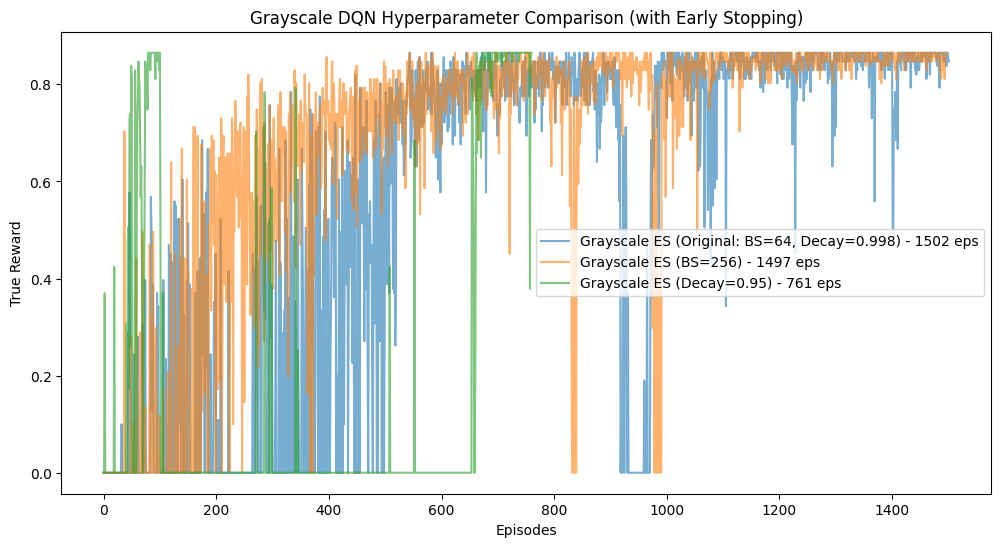

In [22]:
print("--- Hyperparameter Comparison Summary ---")
print(f"1. Grayscale ES (Original: BS=64, Decay=0.998): Converged in {len(rewards_grayscale_es)} episodes")
print(f"2. Grayscale ES (Batch Size = 256, Decay=0.998): Converged in {len(rewards_grayscale_es_bs256)} episodes")
print(f"3. Grayscale ES (Batch Size = 64, Decay=0.95): Converged in {len(rewards_grayscale_es_ed095)} episodes")

plt.figure(figsize=(12, 6))
plt.plot(rewards_grayscale_es, label=f"Grayscale ES (Original: BS=64, Decay=0.998) - {len(rewards_grayscale_es)} eps", alpha=0.6)
plt.plot(rewards_grayscale_es_bs256, label=f"Grayscale ES (BS=256) - {len(rewards_grayscale_es_bs256)} eps", alpha=0.6)
plt.plot(rewards_grayscale_es_ed095, label=f"Grayscale ES (Decay=0.95) - {len(rewards_grayscale_es_ed095)} eps", alpha=0.6)
plt.xlabel("Episodes")
plt.ylabel("True Reward")
plt.title("Grayscale DQN Hyperparameter Comparison (with Early Stopping)")
plt.legend()
plt.show()

### Compare and Test Early Stopping Models

Plots the rewards for the early stopping models, evaluates their performance, and saves/displays the gameplay videos.


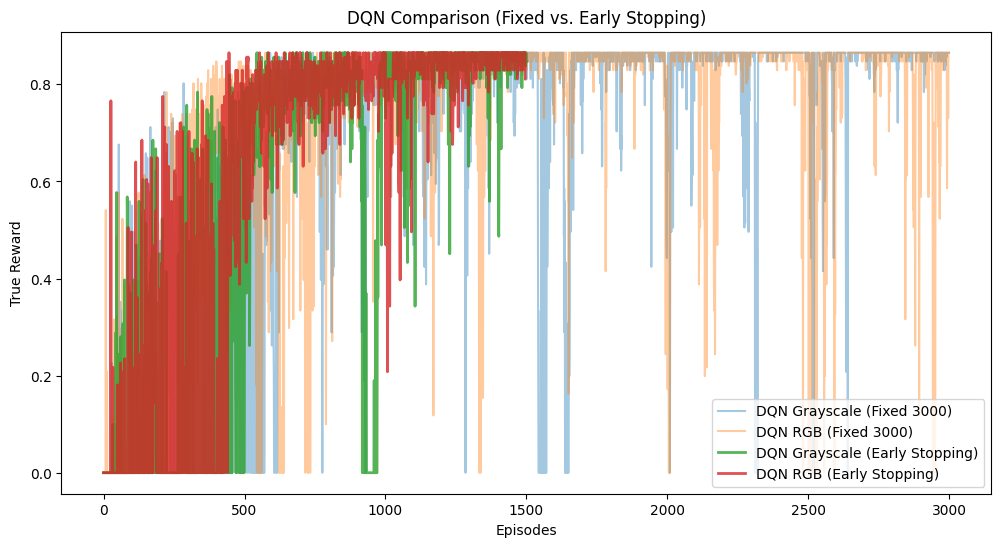

Model loaded from policy_obs3/DQN_Grayscale_ES_save.pth
--- Testing Grayscale ES Model ---
Finished in 15 steps
Video saved to video_obs3/dqn_grayscale_es_play.mp4


Model loaded from policy_obs3/DQN_RGB_ES_save.pth

--- Testing RGB ES Model ---
Finished in 100 steps
Video saved to video_obs3/dqn_rgb_es_play.mp4


In [23]:
# Plot Comparison including Early Stopping Models
plt.figure(figsize=(12, 6))
plt.plot(rewards_grayscale, label="DQN Grayscale (Fixed 3000)", alpha=0.4)
plt.plot(rewards_rgb, label="DQN RGB (Fixed 3000)", alpha=0.4)
plt.plot(rewards_grayscale_es, label="DQN Grayscale (Early Stopping)", alpha=0.8, linewidth=2)
plt.plot(rewards_rgb_es, label="DQN RGB (Early Stopping)", alpha=0.8, linewidth=2)
plt.xlabel("Episodes")
plt.ylabel("True Reward")
plt.title("DQN Comparison (Fixed vs. Early Stopping)")
plt.legend()
plt.show()

# Create Grayscale ES model object and load saved weights
model_grayscale_es = Model((1, 64, 64), 3).to(device)
model_grayscale_es = load_model(model_grayscale_es, "DQN_Grayscale_ES")

print("--- Testing Grayscale ES Model ---")
grayscale_es_frames = test_dqn(model_grayscale_es, use_grayscale=True)
display_video(grayscale_es_frames, "dqn_grayscale_es_play.mp4")

# Create RGB ES model object and load saved weights
model_rgb_es = Model((3, 64, 64), 3).to(device)
model_rgb_es = load_model(model_rgb_es, "DQN_RGB_ES")

print("\n--- Testing RGB ES Model ---")
rgb_es_frames = test_dqn(model_rgb_es, use_grayscale=False)
display_video(rgb_es_frames, "dqn_rgb_es_play.mp4")


In [24]:
# Create Grayscale ES (BS=256) model object and load saved weights
model_grayscale_es_bs256 = Model((1, 64, 64), 3).to(device)
model_grayscale_es_bs256 = load_model(model_grayscale_es_bs256, "DQN_Grayscale_ES_BS256")

print("--- Testing Grayscale ES (BS=256) Model ---")
grayscale_es_bs256_frames = test_dqn(model_grayscale_es_bs256, use_grayscale=True)
display_video(grayscale_es_bs256_frames, "dqn_grayscale_es_bs256_play.mp4")

# Create Grayscale ES (Decay=0.95) model object and load saved weights
model_grayscale_es_ed095 = Model((1, 64, 64), 3).to(device)
model_grayscale_es_ed095 = load_model(model_grayscale_es_ed095, "DQN_Grayscale_ES_ED095")

print("\n--- Testing Grayscale ES (Decay=0.95) Model ---")
grayscale_es_ed095_frames = test_dqn(model_grayscale_es_ed095, use_grayscale=True)
display_video(grayscale_es_ed095_frames, "dqn_grayscale_es_ed095_play.mp4")

Model loaded from policy_obs3/DQN_Grayscale_ES_BS256_save.pth
--- Testing Grayscale ES (BS=256) Model ---
Finished in 15 steps
Video saved to video_obs3/dqn_grayscale_es_bs256_play.mp4


Model loaded from policy_obs3/DQN_Grayscale_ES_ED095_save.pth

--- Testing Grayscale ES (Decay=0.95) Model ---
Finished in 15 steps
Video saved to video_obs3/dqn_grayscale_es_ed095_play.mp4
